##Social Media Engagement Analytics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
#Task 1 — Data Import & Setup
url="https://raw.githubusercontent.com/gomathivvm-9496/social_media_engagement_5000/refs/heads/main/social_media_engagement_5000.csv"

df=pd.read_csv(url)
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [ ]:
df.shape

(5000, 19)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
df["posted_at"]=pd.to_datetime(df["posted_at"],format="%d-%m-%Y")
df["posted_at"].dtypes

dtype('<M8[ns]')

In [ ]:
#Data Cleaning

#Cleaning Missing Data
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
numerical_cols=["likes","comments","shares"]
for col in numerical_cols:
  df[col]=df[col].fillna(df[col].median())


In [ ]:
categorical_cols=["gender","sentiment"]
for col in categorical_cols:
  df[col]=df[col].fillna(df[col].mode()[0])

In [ ]:
df["age"]=df["age"].fillna(df["age"].median())

In [ ]:
df.isna().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
#Duplicate Handling
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
#Data Formatting
num_cols=["age","likes","comments","shares"]
for col in num_cols:
  df[col]=df[col].astype(int)

In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [ ]:
#Standardize categories
df["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [ ]:
df["country"].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [ ]:
df["device_type"].unique()

array(['mobile', 'tablet', 'desktop'], dtype=object)

In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029


In [ ]:
#Feature Cleaning
df["hashtag_count"]=df["hashtags"].str.count("#")
df["hashtag_count"]=df["hashtag_count"].fillna(0)
df["hashtag_count"]=df["hashtag_count"].astype(int)
df["hashtag_count"]

,hashtag_count
0,3
1,1
2,1
3,3
4,1
...,...
4995,2
4996,2
4997,2
4998,3


In [ ]:
df["sentiment"].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [ ]:
#Data Exploration using Pandas
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [ ]:
df["post_type"].value_counts()

,count
post_type,
reel,1283
image,1247
text,1245
video,1225


In [ ]:
df["country"].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [ ]:
df["country"].nunique()

10

In [ ]:
#Correlation Matrix
corr=df.corr(numeric_only=True)
corr

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036323,-0.007284,0.013871,0.005542,0.013322,-0.024894,-0.000079,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.025208,0.010139,0.007344
likes,0.025811,-0.036323,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,-0.016199,0.093521,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.012398,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.007025,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.012326,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,0.008317,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.008802
is_verified,0.004058,-0.000079,0.025208,-0.016199,-0.012398,0.007025,0.012326,0.008317,-0.017808,1.000000,0.005528,0.001396


In [ ]:
#Average likes by post type
df.groupby("post_type")["likes"].mean()

,likes
post_type,
image,10104.852446
reel,10037.784879
text,10100.132530
video,10188.586122


In [ ]:
#Impressions by country
df.groupby("country")["impression_count"].mean()

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [ ]:
# Data Wrangling
df["engagement_score"]=df["likes"]+df["comments"]+df["shares"]
df["engagement_score"]


,engagement_score
0,8522
1,16163
2,6161
3,7482
4,16717
...,...
4995,20060
4996,21241
4997,15151
4998,19896


In [ ]:
 #log-transformed metrics
df["log_likes"]=np.log1p(df["likes"])
df["log_comments"]=np.log1p(df["comments"])
df["log_shares"]=np.log1p(df["shares"])

In [ ]:
df.groupby("country")["engagement_score"].mean()

,engagement_score
country,
Australia,12809.604462
Brazil,12385.972222
Canada,12605.883041
France,12903.370968
Germany,12635.640816
India,12492.678505
Japan,12578.637712
UAE,12757.763419
UK,12384.361055


In [ ]:
df.groupby("post_type")["engagement_score"].mean()

,engagement_score
post_type,
image,12649.377706
reel,12524.014030
text,12613.228112
video,12664.580408


In [ ]:
df.groupby("sentiment")["engagement_score"].mean()

,engagement_score
sentiment,
negative,12731.483333
neutral,12448.149312
positive,12665.784322


In [ ]:
#Statistical Analysis
cols=["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]
df[cols].mean()

,0
likes,10106.982400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [ ]:
df[cols].median()

,0
likes,10105.000000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
df[cols].mode().iloc[0]

,0
likes,10105.000000
comments,1497.000000
shares,1012.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [ ]:
df[cols].std()

,0
likes,5702.293022
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [ ]:
df[cols].var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [ ]:
df[cols].quantile([0.25,0.5,0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.0,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [ ]:
df[cols].skew()

,0
likes,-0.006886
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [ ]:
df[cols].kurtosis()

,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


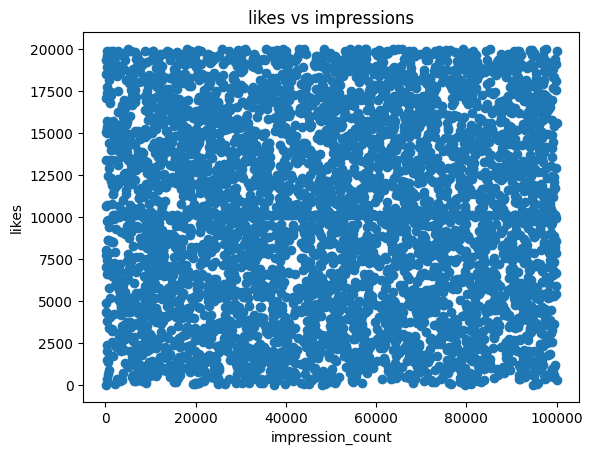

In [ ]:
#Data Visualization
#Scatter: likes vs impressions
plt.scatter(df["impression_count"],df["likes"])
plt.xlabel("impression_count")
plt.ylabel("likes")
plt.title("likes vs impressions")
plt.show()

In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


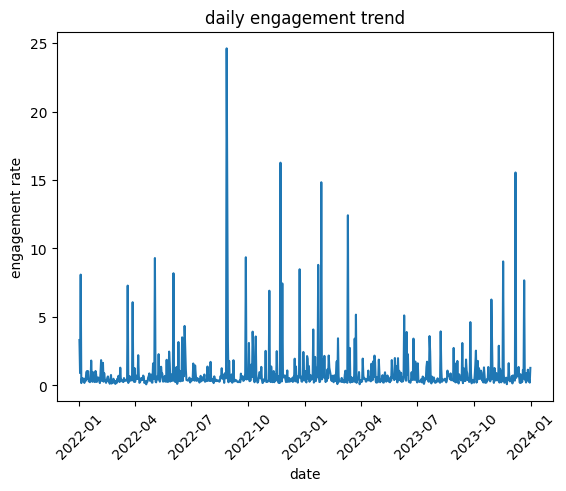

In [ ]:
#Line: daily engagement trend
df["date"]=df["posted_at"].dt.date
daily_engagement=df.groupby("date")["engagement_rate"].mean()
plt.plot(daily_engagement.index,daily_engagement.values)
plt.xlabel("date")
plt.ylabel("engagement rate")
plt.title("daily engagement trend")
plt.xticks(rotation=45)
plt.show()

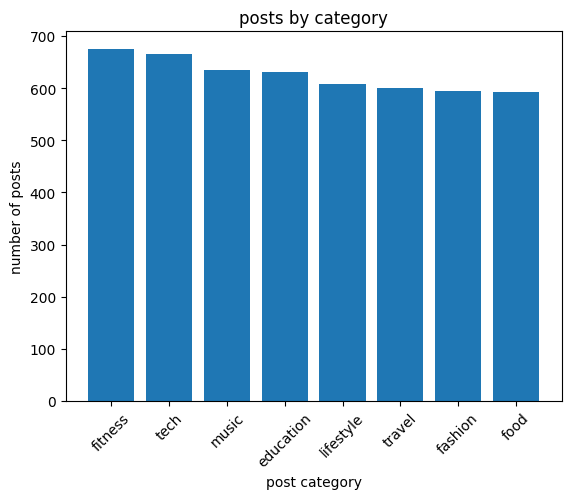

In [ ]:
#Bar: posts by category
category_counts=df["post_category"].value_counts()
plt.bar(category_counts.index,category_counts.values)
plt.xlabel("post category")
plt.ylabel("number of posts")
plt.title("posts by category")
plt.xticks(rotation=45)
plt.show()

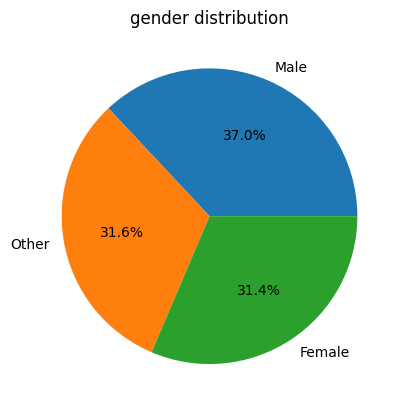

In [ ]:
#Pie: gender distribution
gender_count=df["gender"].value_counts()
plt.pie(gender_count,labels=gender_count.index,autopct="%1.1f%%")
plt.title("gender distribution")
plt.show()

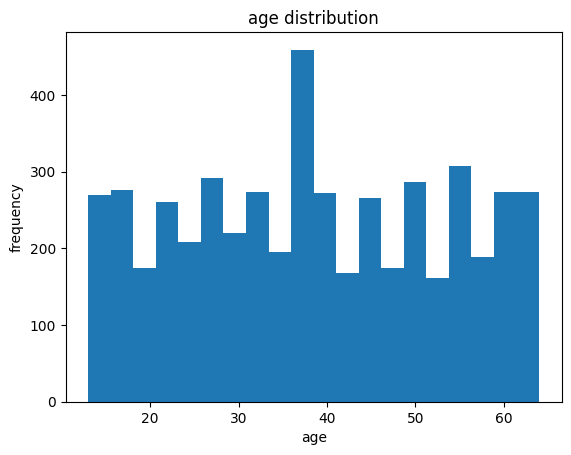

In [ ]:
#Histogram: age
plt.hist(df["age"],bins=20)
plt.xlabel("age")
plt.ylabel("frequency")
plt.title("age distribution")
plt.show()

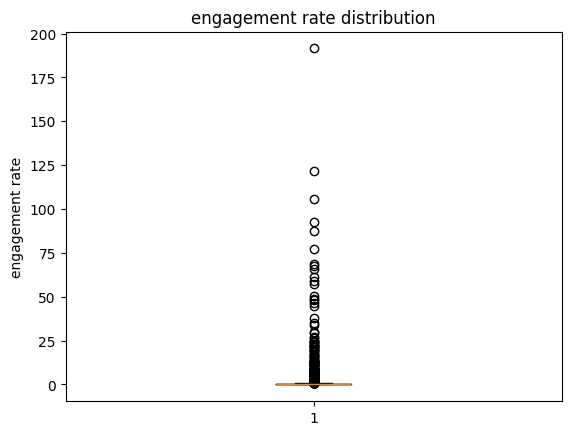

In [ ]:
#Box: engagement rate
plt.boxplot(df["engagement_rate"])
plt.title("engagement rate distribution")
plt.ylabel("engagement rate")
plt.show()

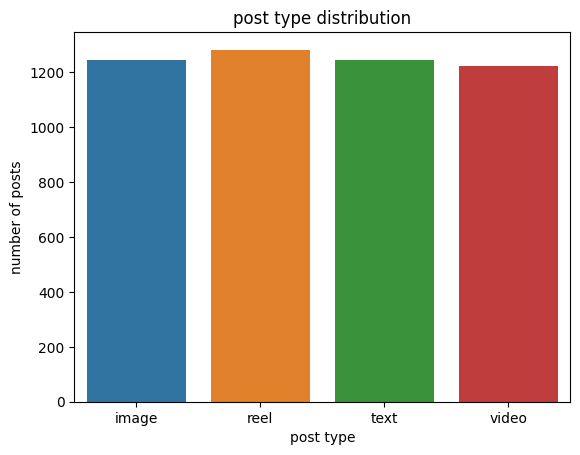

In [ ]:
#Seaborn
#Count plot: post type
sns.countplot(data=df,x="post_type",hue="post_type")
plt.xlabel("post type")
plt.ylabel("number of posts")
plt.title("post type distribution")
plt.show()

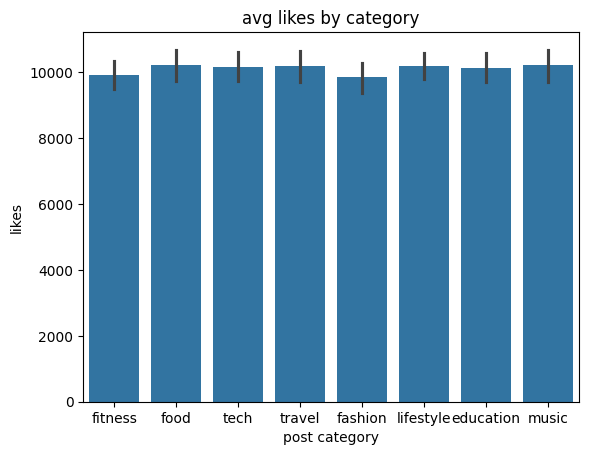

In [ ]:
#Bar plot: avg likes by category

sns.barplot(data=df,x="post_category",y="likes")
plt.xlabel("post category")
plt.ylabel("likes")
plt.title("avg likes by category")
plt.show()


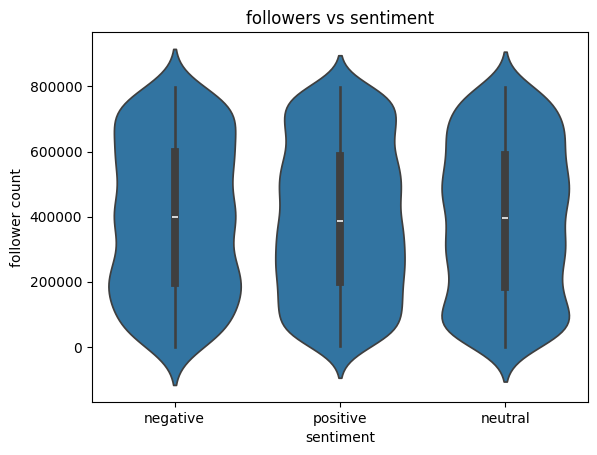

In [ ]:
#Violin: followers vs sentiment

sns.violinplot(data=df,x="sentiment",y="follower_count")
plt.xlabel("sentiment")
plt.ylabel("follower count")
plt.title("followers vs sentiment")
plt.show()

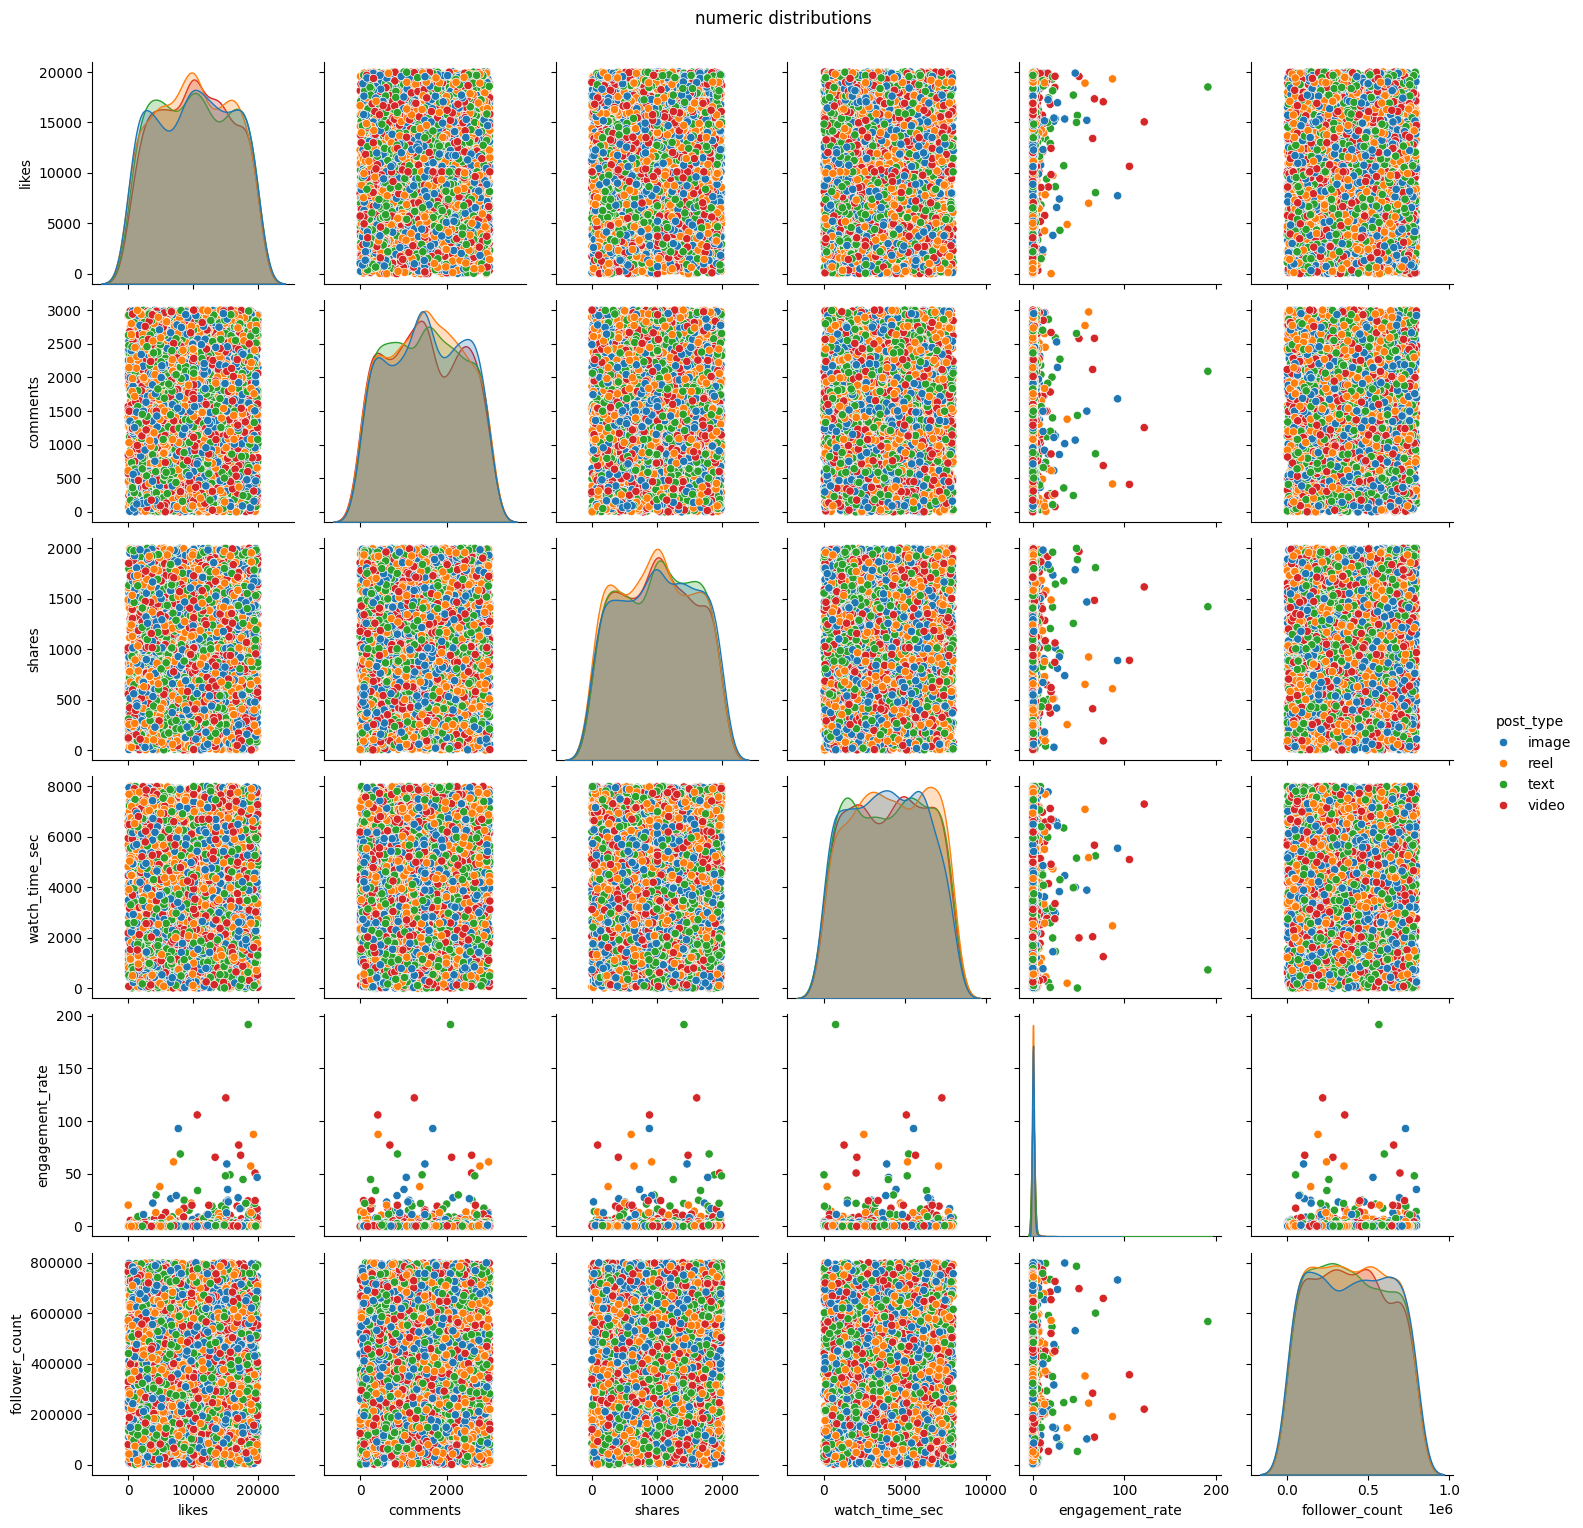

In [ ]:
#Pair plot: numeric features
cols=["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]
sns.pairplot(df,vars=cols,hue="post_type",diag_kind="kde")
plt.suptitle("numeric distributions",y=1.02)
plt.show()

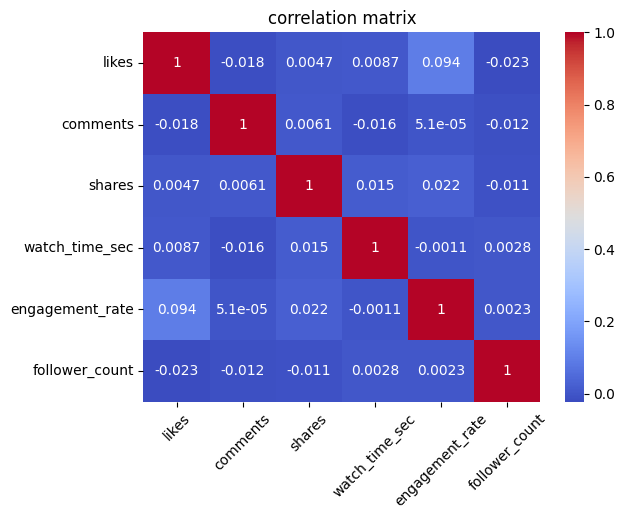

In [ ]:
#Heatmap: correlation matrix
cols=["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]
cols_corr=df[cols].corr()
sns.heatmap(cols_corr,annot=True,cmap="coolwarm")
plt.title("correlation matrix")
plt.xticks(rotation=45)
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

69.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

78.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

74.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

73.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

82.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categor

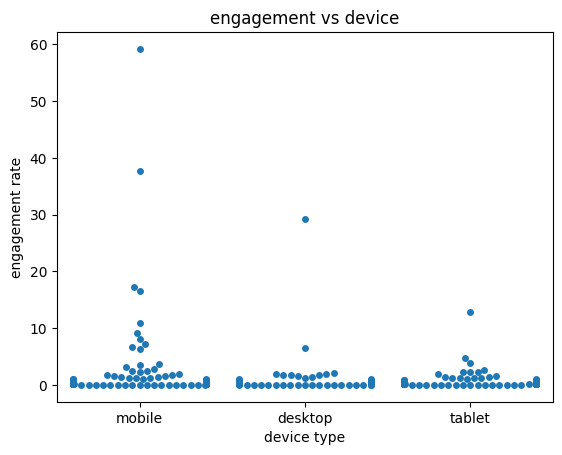

In [ ]:
#Swarm plot: engagement vs device

sns.swarmplot(data=df.sample(500),x="device_type",y="engagement_rate")
plt.xlabel("device type")
plt.ylabel("engagement rate")
plt.title("engagement vs device")
plt.show()


In [ ]:
#Plotly (Interactive)
#Daily engagement trend
daily=df.groupby("posted_at")["engagement_rate"].mean().reset_index()
fig=px.line(daily,x="posted_at",y="engagement_rate",title="daily engagement trend")
fig.show()

In [ ]:
#Interactive Bar Chart
#Average shares by post category
avg_shares=df.groupby("post_category")["shares"].mean().reset_index()
fig=px.bar(avg_shares,x="post_category",y="shares",title="Average shares by post category")
fig.show()

In [ ]:
#Interactive Bubble Chart
fig=px.scatter(df,x="likes",y="shares",size="comments",color="post_type",title="engagement analysis")
fig.show()

In [ ]:
#Interactive Scatter Plot
fig=px.scatter(df,x="impression_count",y="likes",color="post_type",title="likes vs impression")
fig.show()